In [1]:
from google.colab import files
uploaded=files.upload()

Saving netflix_titles.csv to netflix_titles.csv


#Netflix Movies & TV Shows Analysis
Exploratory Data Analysis using NumPy, Pandas, Matplotlib and Seaborn
##Author
Tejaswi K

##Objective
The objective of this project is to analyze Netflix's catalog of movies and TV shows to identify trends, patterns, and business insights using Exploratory Data Analysis (EDA).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv('netflix_titles.csv')
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


#Understanding the dataset
## Overview

Before performing any analysis, it is important to understand the structure and quality of the dataset. This phase focuses on exploring the dataset to identify the number of records, available features, data types, missing values, duplicate records, and overall data quality.

### Objectives
- Load the Netflix dataset into Pandas.
- Examine the size and structure of the dataset.
- Understand the meaning of each column.
- Identify missing values and duplicate records.
- Review the data types of each feature.
- Generate summary statistics for numerical columns.

This initial exploration provides a strong foundation for the data cleaning and exploratory data analysis performed in the following phases.

In [3]:
df.shape

(5837, 12)

df.columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [5]:
df.describe()

,show_id,release_year
count,5.837000e+03,5837.000000
mean,7.730079e+07,2013.688539
std,9.479777e+06,8.419088
min,2.698800e+05,1925.000000
25%,8.004520e+07,2013.000000
50%,8.016353e+07,2016.000000
75%,8.024188e+07,2018.000000
max,8.122720e+07,2020.000000


In [6]:
df.describe(include='all')

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
count,5.837000e+03,5837,3936,5281,5410,5195,5837.000000,5827,5837,5837,5837,5837
unique,NaN,5780,3108,5087,527,1092,NaN,14,194,449,5829,2
top,NaN,Oh My Ghost,"Raúl Campos, Jan Suter",David Attenborough,United States,"November 1, 2019",NaN,TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...,Movie
freq,NaN,3,18,18,1907,94,NaN,1937,1259,297,3,3939
mean,7.730079e+07,NaN,NaN,NaN,NaN,NaN,2013.688539,NaN,NaN,NaN,NaN,NaN
std,9.479777e+06,NaN,NaN,NaN,NaN,NaN,8.419088,NaN,NaN,NaN,NaN,NaN
min,2.698800e+05,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN,NaN
25%,8.004520e+07,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN
50%,8.016353e+07,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN
75%,8.024188e+07,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Phase 2: Data Cleaning

## Objective
The objective of this phase is to clean and preprocess the Netflix dataset before performing Exploratory Data Analysis (EDA). Data cleaning improves the quality, consistency, and reliability of the dataset by handling missing values, removing duplicate records, correcting data types, and standardizing the data. A clean dataset ensures that the analysis produces accurate and meaningful insights.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['date_added']=pd.to_datetime(df['date_added'])

date_added is now datetime64[ns]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5837 non-null   int64         
 1   title         5837 non-null   object        
 2   director      3936 non-null   object        
 3   cast          5281 non-null   object        
 4   country       5410 non-null   object        
 5   date_added    5195 non-null   datetime64[ns]
 6   release_year  5837 non-null   int64         
 7   rating        5827 non-null   object        
 8   duration      5837 non-null   object        
 9   listed_in     5837 non-null   object        
 10  description   5837 non-null   object        
 11  type          5837 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 547.3+ KB


In [14]:
df.isnull().sum()

,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


#handling Missing Values

In [15]:
df['country']=df['country'].fillna('unkown')
df

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,2019-11-30,2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,unkown,2019-11-30,2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,2019-11-30,2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium",2019-11-29,2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaT,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show
...,...,...,...,...,...,...,...,...,...,...,...,...
5832,70141644,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,2010-11-01,1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",Movie
5833,70127998,Splatter,Joe Dante,"Corey Feldman, Tony Todd, Tara Leigh, Erin Way...",United States,2009-11-18,2009,TV-14,29 min,Horror Movies,"After committing suicide, a washed-up rocker r...",Movie
5834,70084180,Just Another Love Story,Ole Bornedal,"Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...",Denmark,2009-05-05,2007,NR,104 min,"Dramas, International Movies",When he causes a car accident that leaves a yo...,Movie
5835,70157452,Dinner for Five,NaN,NaN,United States,2008-02-04,2007,TV-MA,1 Season,Stand-Up Comedy & Talk Shows,"In each episode, four celebrities join host Jo...",TV Show


In [16]:
df['rating'].fillna(df['rating'].mode()[0],inplace=True)

In [17]:
df=df.dropna(subset=['duration'])

### Handling Missing Values
- Filled missing country values with "Unknown".
- Filled missing ratings using the most frequent rating.
- Removed records with missing duration values.

In [18]:
df['country']=df['country'].str.strip()
df['country']

,country
0,South Korea
1,unkown
2,India
3,"France, Senegal, Belgium"
4,"Canada, United Kingdom"
...,...
5832,United States
5833,United States
5834,Denmark
5835,United States


#country cleaning
-removed leading and trailing spaces from country names

In [19]:
df['listed_in'].str.strip()

,listed_in
0,"International TV Shows, Korean TV Shows, Roman..."
1,"Documentaries, International Movies"
2,"Comedies, Dramas, International Movies"
3,"Dramas, Independent Movies, International Movies"
4,Kids' TV
...,...
5832,"Cult Movies, Horror Movies"
5833,Horror Movies
5834,"Dramas, International Movies"
5835,Stand-Up Comedy & Talk Shows


In [20]:
df.to_csv('netflix_cleaned.csv',index=False)

###Clean dataset
-Saved the clean dataset as 'netflix.cleaned_csv'
-this data will be used for the Exploratary Data Analysis

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5837 non-null   int64         
 1   title         5837 non-null   object        
 2   director      3936 non-null   object        
 3   cast          5281 non-null   object        
 4   country       5837 non-null   object        
 5   date_added    5195 non-null   datetime64[ns]
 6   release_year  5837 non-null   int64         
 7   rating        5837 non-null   object        
 8   duration      5837 non-null   object        
 9   listed_in     5837 non-null   object        
 10  description   5837 non-null   object        
 11  type          5837 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 547.3+ KB


#Phase 3: Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is performed to understand the cleaned Netflix dataset by identifying patterns, trends, and relationships using statistical summaries and visualizations. The insights obtained from EDA help answer important business questions and support data-driven decision making.

#3.1 Dataset Overview
Objective
Understand the structure and basic statistics of the cleaned dataset.

In [22]:
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,2019-11-30,2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,unkown,2019-11-30,2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,2019-11-30,2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium",2019-11-29,2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaT,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [23]:
df.tail()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
5832,70141644,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,2010-11-01,1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",Movie
5833,70127998,Splatter,Joe Dante,"Corey Feldman, Tony Todd, Tara Leigh, Erin Way...",United States,2009-11-18,2009,TV-14,29 min,Horror Movies,"After committing suicide, a washed-up rocker r...",Movie
5834,70084180,Just Another Love Story,Ole Bornedal,"Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...",Denmark,2009-05-05,2007,NR,104 min,"Dramas, International Movies",When he causes a car accident that leaves a yo...,Movie
5835,70157452,Dinner for Five,NaN,NaN,United States,2008-02-04,2007,TV-MA,1 Season,Stand-Up Comedy & Talk Shows,"In each episode, four celebrities join host Jo...",TV Show
5836,70053412,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,2008-01-01,2006,NR,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea...",Movie


In [24]:
df.shape

(5837, 12)

In [25]:
df.columns

Index(['show_id', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'type'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5837 non-null   int64         
 1   title         5837 non-null   object        
 2   director      3936 non-null   object        
 3   cast          5281 non-null   object        
 4   country       5837 non-null   object        
 5   date_added    5195 non-null   datetime64[ns]
 6   release_year  5837 non-null   int64         
 7   rating        5837 non-null   object        
 8   duration      5837 non-null   object        
 9   listed_in     5837 non-null   object        
 10  description   5837 non-null   object        
 11  type          5837 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 547.3+ KB


In [27]:
df.describe(include='all')

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
count,5.837000e+03,5837,3936,5281,5837,5195,5837.000000,5837,5837,5837,5837,5837
unique,NaN,5780,3108,5087,528,NaN,NaN,14,194,449,5829,2
top,NaN,Oh My Ghost,"Raúl Campos, Jan Suter",David Attenborough,United States,NaN,NaN,TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...,Movie
freq,NaN,3,18,18,1907,NaN,NaN,1947,1259,297,3,3939
mean,7.730079e+07,NaN,NaN,NaN,NaN,2018-05-19 01:10:41.000962560,2013.688539,NaN,NaN,NaN,NaN,NaN
min,2.698800e+05,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,NaN
25%,8.004520e+07,NaN,NaN,NaN,NaN,2017-09-01 00:00:00,2013.000000,NaN,NaN,NaN,NaN,NaN
50%,8.016353e+07,NaN,NaN,NaN,NaN,2018-08-02 00:00:00,2016.000000,NaN,NaN,NaN,NaN,NaN
75%,8.024188e+07,NaN,NaN,NaN,NaN,2019-04-10 00:00:00,2018.000000,NaN,NaN,NaN,NaN,NaN
max,8.122720e+07,NaN,NaN,NaN,NaN,2019-11-30 00:00:00,2020.000000,NaN,NaN,NaN,NaN,NaN


#Observation
The dataset contains information about Netflix movies and TV shows, including title, director, cast, country, release year, rating, duration, genre, and date added. Understanding the dataset structure helps in selecting appropriate columns for further analysis.

#3.2 Content Type Distribution (Movies vs TV Shows)
Objective
Analyze the proportion of Movies and TV Shows available on Netflix.

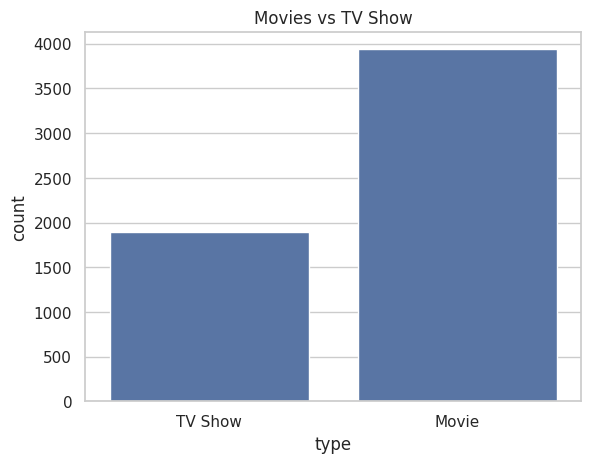

In [28]:
sns.countplot(x='type',data=df)
plt.title('Movies vs TV Show')
plt.show()

#Observation
Movies dominate the Netflix catalog, while TV Shows represent a smaller proportion.

#3.3 Rating Distribution
Objective
Identify the most common audience ratings.

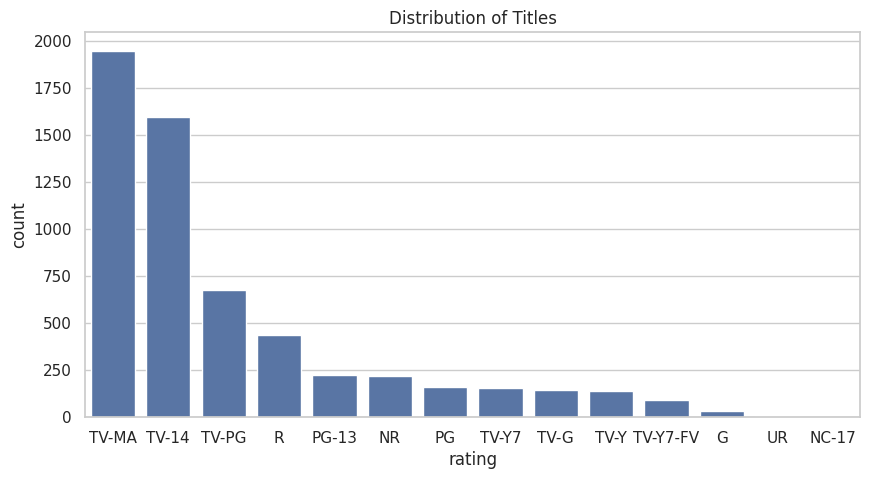

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating',data=df,
order=df['rating'].value_counts().index)
plt.title('Distribution of Titles')
plt.show()

#Observation
TV-MA, TV-14, and PG-13 are among the most frequent content ratings, indicating that Netflix contains a large amount of mature and teenage content.

#3.4 Top 10 Genres on Netflix
Objective
Find the most common genres available.

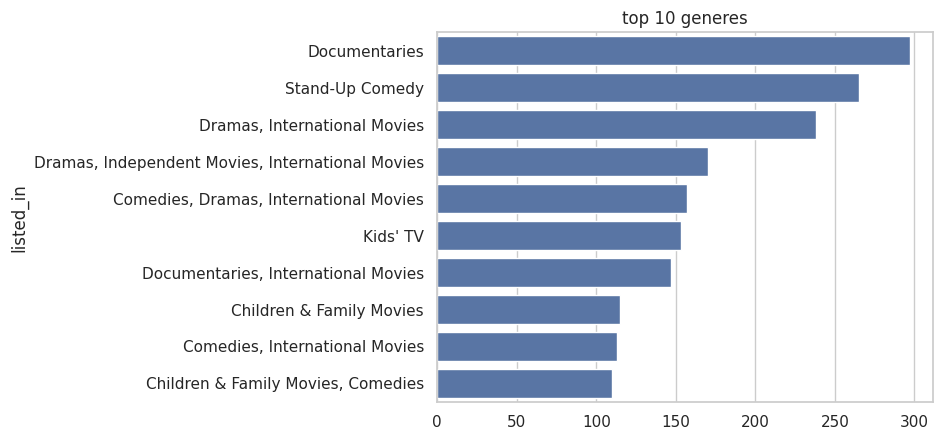

In [30]:
top_generes=df['listed_in'].value_counts().head(10)
sns.barplot(x=top_generes.values,y=top_generes.index)
plt.title('top 10 generes')
plt.show()

#Observation
Drama, International Movies, Comedy, and Documentaries are among the most popular genres.

#3.5 Top 10 Countries Producing Netflix Content
Objective
Identify countries contributing the most content.

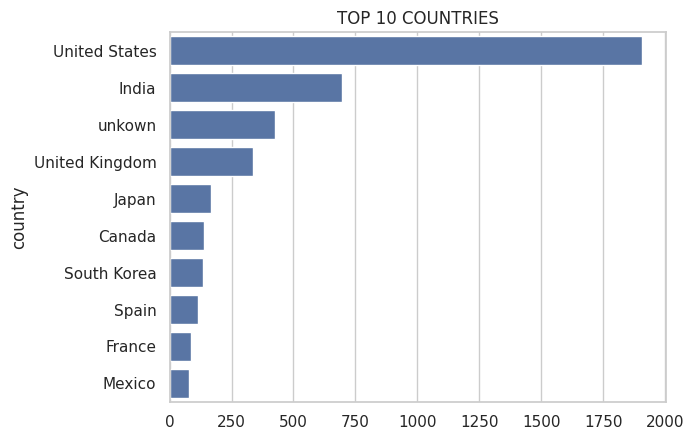

In [31]:
top_country=df['country'].value_counts().head(10)
sns.barplot(x=top_country.values,y=top_country.index)
plt.title('TOP 10 COUNTRIES')
plt.ylabel('country')
plt.show()

#Observation
The United States contributes the highest number of titles, followed by India and the United Kingdom.

#3.6 Content Added Over the Years
Objective
Analyze Netflix's growth over time.

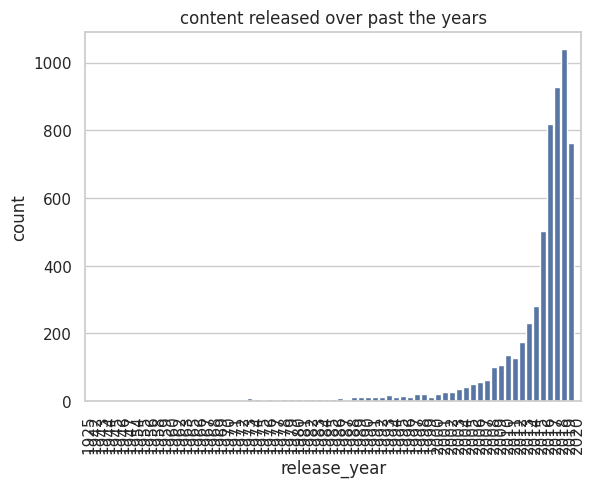

In [32]:
sns.countplot(x='release_year',data=df,order=df['release_year'].value_counts().sort_index().index)
plt.xticks(rotation=90)
plt.title("content released over past the years")
plt.show()

#Observation
Netflix content increased rapidly after 2015, reflecting the platform's global expansion.

#3.7 Movies vs TV Shows Released by Year
Objective
Compare yearly releases of Movies and TV Shows.

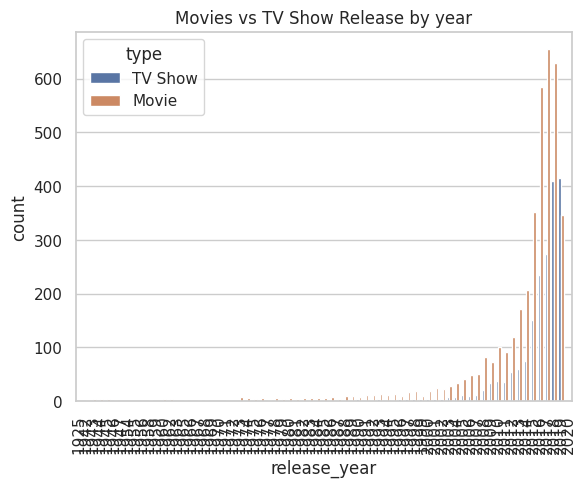

In [33]:
sns.countplot(x='release_year',hue='type',data=df)
plt.title('Movies vs TV Show Release by year')
plt.xticks(rotation=90)
plt.show()

#Observation
Movies consistently outnumber TV Shows across most years.

##3.8 Movie Duration Analysis
Objective
Study the duration of Netflix movies.

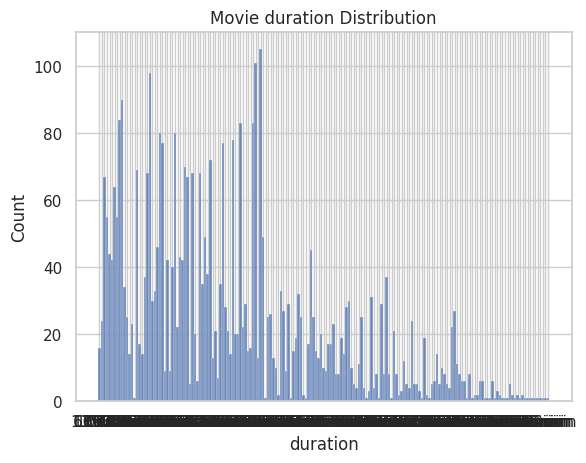

In [34]:
movies=df[df['type']=='Movie']
sns.histplot(x=movies['duration'],bins=20)
plt.title("Movie duration Distribution")
plt.show()

#Observation
Most Netflix movies have durations between 80 and 120 minutes.

#3.9 Top Directors on Netflix
Objective
Find directors with the highest number of titles.

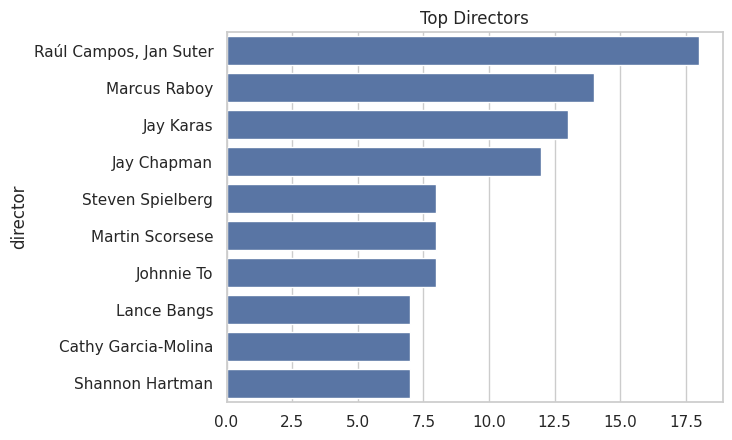

In [35]:
top_directors=df['director'].value_counts().head(10)
sns.barplot(x=top_directors.values,y=top_directors.index)
plt.title('Top Directors')
plt.show()

#Observation
A few directors contribute multiple titles, while many directors have only one or two productions.

#3.10 Top Actors on Netflix
Objective
Identify actors appearing most frequently.

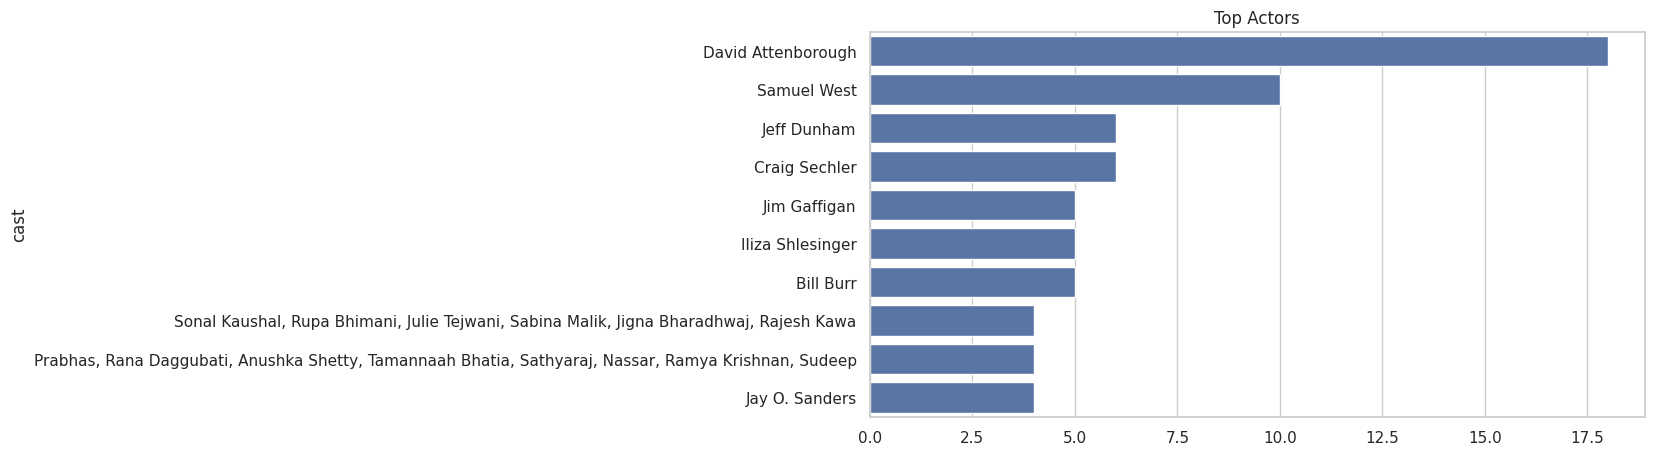

In [36]:
top_actors=df['cast'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_actors.values,y=top_actors.index)
plt.title('Top Actors')
plt.show()

##Observation
Some actors appear repeatedly across multiple Netflix titles, indicating frequent collaborations.

#3.11 Correlation Analysis (Optional)
Objective
Check relationships among numerical features.

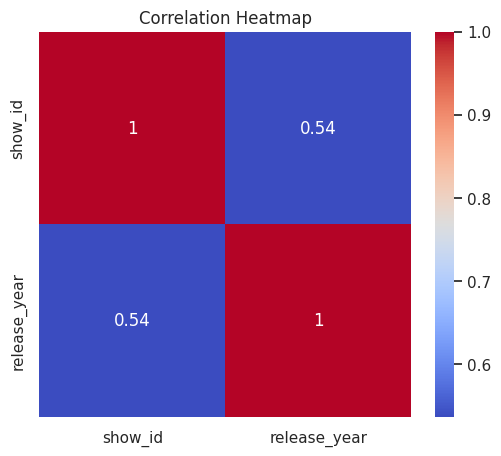

In [37]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Observation
The heatmap shows the correlation between numerical variables. Strong positive or negative correlations indicate relationships between features.

#Conclusion
The Exploratory Data Analysis revealed important trends in the Netflix dataset. Visualizations helped understand content distribution, ratings, genres, countries, release patterns, and movie durations. These insights can support recommendation systems, business analysis, and future machine learning applications.

# Phase 4: Advanced Data Analysis & Business Insights

## Objective

The objective of this phase is to perform advanced data analysis on the cleaned Netflix dataset using Pandas. This phase focuses on answering important business questions through feature engineering, grouping, filtering, sorting, pivot tables, merging, and aggregation techniques. The analysis helps uncover patterns, trends, and insights about Netflix's content library.

## 4.1 Top Content Producing Countries

Analyze which countries contribute the highest number of titles to Netflix.

In [38]:
top_countries=df.groupby('country')['show_id'].count().sort_values(ascending=False).head(10)
top_countries


,show_id
country,
United States,1907
India,697
unkown,427
United Kingdom,336
Japan,168
Canada,139
South Korea,133
Spain,113
France,85


## 4.2 Top Directors on Netflix

Identify the directors who have released the highest number of titles on Netflix.

In [39]:
top_directors=df['director'].value_counts().head(10)
top_directors

,count
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,14
Jay Karas,13
Jay Chapman,12
Steven Spielberg,8
Martin Scorsese,8
Johnnie To,8
Lance Bangs,7
Cathy Garcia-Molina,7


## 4.3 Content Distribution by Release Year

Analyze how Movies and TV Shows are distributed across different release years.

In [40]:
release_year=df.groupby(['release_year','type'])['show_id'].count().unstack(fill_value=0)
release_year

type,Movie,TV Show
release_year,,
1925,0,1
1942,2,0
1943,3,0
1944,3,0
1945,3,0
...,...,...
2016,584,234
2017,655,273
2018,630,410


## 4.4 Distribution of Content Ratings

Study how Netflix content is distributed across different maturity ratings.

In [41]:
ratings=pd.crosstab(df['type'],df['rating'])
ratings

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,31,2,202,160,227,437,955,79,1296,413,41,62,27,7
TV Show,1,0,16,0,0,2,638,68,651,265,98,94,65,0


## 4.5 Movies vs TV Shows Across Countries

Compare the number of Movies and TV Shows produced by each country.

In [42]:
country_type = pd.pivot_table(
    df,
    values="show_id",
    index="country",
    columns="type",
    aggfunc="count",
    fill_value=0
)
country_type

type,Movie,TV Show
country,,
Argentina,26,12
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,4,0


## 4.6 Most Popular Genres by Country

Identify the most popular genres available in different countries.

In [43]:
popular_genres=df.groupby(['country','listed_in'])['show_id'].count().head(10)
popular_genres

country    listed_in                                                        
Argentina  Action & Adventure, Comedies, International Movies                   1
           Action & Adventure, Horror Movies, International Movies              1
           Children & Family Movies, Music & Musicals                           1
           Comedies, Cult Movies, International Movies                          1
           Comedies, International Movies                                       1
           Comedies, International Movies, Romantic Movies                      1
           Crime TV Shows, International TV Shows, Spanish-Language TV Shows    4
           Documentaries, International Movies                                  1
           Documentaries, International Movies, Sports Movies                   2
           Dramas, Independent Movies, International Movies                     2
Name: show_id, dtype: int64

## 4.7 Content Added Over Time

Analyze the month and year in which Netflix added the highest number of titles.

In [44]:
df['year_added']=pd.to_datetime(df['date_added']).dt.year
df['month_added']=pd.to_datetime(df['date_added']).dt.month_name()
content_added=df.groupby(['year_added','month_added'])['show_id'].count().head(10).unstack()
content_added

month_added,February,January,May,November,October,September,August,December
year_added,,,,,,,,
2008.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2009.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
2010.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
2011.0,NaN,NaN,1.0,NaN,11.0,1.0,NaN,NaN
2012.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


## 4.8 Longest Movies on Netflix

Identify the longest movies available on the Netflix platform.

In [45]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
    .astype(int)
)

longest_movies = movies.sort_values(
    by="duration",
    ascending=False
).head(20)

print(longest_movies[["title", "duration"]])

                           title  duration
2160  Black Mirror: Bandersnatch       312
4009                      Lagaan       224
2651                Jodhaa Akbar       214
27                  The Irishman       209
2552          The Gospel of Luke       205
2928        What's Your Raashee?       203
211               Doctor Zhivago       200
2876      Elephants Dream 4 Hour       196
3496            Schindler's List       195
3877         Hum Aapke Hain Koun       193
3887             Maine Pyar Kiya       192
2554       The Gospel of Matthew       190
3647                      Pardes       187
3663                      Swades       185
251         Mutiny on the Bounty       185
552                 King of Boys       182
5472   Blue Is the Warmest Color       180
5133              Happy New Year       179
3665                        Taal       177
823                         Manu       177


## 4.9 Average Movie Duration by Rating

Compare the average duration of movies across different rating categories.

In [46]:
avg_duration = (
    movies.groupby("rating")["duration"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_duration)

rating
NC-17       131.500000
UR          110.000000
PG-13       107.493392
TV-14       106.398953
R           105.830664
PG           97.950000
TV-PG        97.549637
NR           95.123762
TV-MA        94.658951
G            81.870968
TV-G         67.607595
TV-Y7        58.645161
TV-Y7-FV     55.222222
TV-Y         48.414634
Name: duration, dtype: float64


## 4.10 Advanced Filtering of Netflix Titles

Filter Indian movies released after 2018 with a TV-MA rating.

In [47]:
filtered = df[
    (df["country"] == "India") &
    (df["type"] == "Movie") &
    (df["release_year"] > 2018) &
    (df["rating"] == "TV-MA")
]

print(filtered[["title", "release_year", "rating"]])

                          title  release_year rating
34                      Pranaam          2019  TV-MA
110                    Guna 369          2019  TV-MA
172       Oththa Seruppu Size 7          2019  TV-MA
417                    Noblemen          2019  TV-MA
547                Manmadhudu 2          2019  TV-MA
570                 Kabir Singh          2019  TV-MA
626                  Article 15          2019  TV-MA
807                   Uriyadi 2          2019  TV-MA
1035               Super Deluxe          2019  TV-MA
1084                   Rakkhosh          2019  TV-MA
1221                 Chopsticks          2019  TV-MA
1226  Mere Pyare Prime Minister          2019  TV-MA
1817                  Firebrand          2019  TV-MA


## 4.11 Merging External Country Information

Merge the Netflix dataset with additional country information for enhanced analysis.

In [48]:
country_info = pd.DataFrame({
    "country": [
        "India",
        "United States",
        "United Kingdom",
        "Canada",
        "Japan"
    ],
    "continent": [
        "Asia",
        "North America",
        "Europe",
        "North America",
        "Asia"
    ]
})

merged_df = df.merge(
    country_info,
    on="country",
    how="left"
)

print(merged_df.head())

    show_id                                title                    director  \
0  81193313                            Chocolate                         NaN   
1  81197050  Guatemala: Heart of the Mayan World  Luis Ara, Ignacio Jaunsolo   
2  81213894                      The Zoya Factor             Abhishek Sharma   
3  81082007                            Atlantics                   Mati Diop   
4  80213643                      Chip and Potato                         NaN   

                                                cast  \
0  Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...   
1                                  Christian Morales   
2  Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...   
3  Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...   
4  Abigail Oliver, Andrea Libman, Briana Buckmast...   

                    country date_added  release_year rating   duration  \
0               South Korea 2019-11-30          2019  TV-14   1 Season   
1                    unkown 2019-1

## 4.12 Business Dashboard Using Pivot Tables

Create a pivot table to summarize the distribution of Movies and TV Shows across different countries.

In [49]:
dashboard = pd.pivot_table(
    df,
    values="show_id",
    index="country",
    columns="type",
    aggfunc="count",
    fill_value=0,
    margins=True
)

print(dashboard)

type                                                Movie  TV Show   All
country                                                                 
Argentina                                              26       12    38
Argentina, Brazil, France, Poland, Germany, Den...      1        0     1
Argentina, Chile                                        1        0     1
Argentina, Chile, Peru                                  1        0     1
Argentina, France                                       1        0     1
...                                                   ...      ...   ...
Venezuela, Colombia                                     1        0     1
Vietnam                                                 4        0     4
West Germany                                            1        0     1
unkown                                                170      257   427
All                                                  3939     1898  5837

[529 rows x 3 columns]


## Conclusion

In this phase, advanced data analysis techniques were applied to the Netflix dataset to extract meaningful business insights. Operations such as feature engineering, GroupBy, Pivot Tables, Crosstab, Merge, Filtering, Sorting, and Aggregation were used to analyze content distribution across countries, directors, genres, ratings, release years, and content types. The analysis highlighted key trends in Netflix's content library and demonstrated the practical use of Pandas for solving real-world business problems. This phase strengthened the dataset by transforming raw data into actionable insights, making it suitable for further analysis and machine learning applications.

# 📌 Phase 5: Insights, Conclusion & Future Scope

## 🎯 Objective
The objective of this phase is to summarize the key findings obtained from the Exploratory Data Analysis (EDA) and present the overall conclusion of the project.

---

## 🔍 Key Insights

- 🎬 **Movies dominate Netflix's library**, indicating that Netflix offers more movies than TV Shows.
- 📈 The number of titles added to Netflix **increased significantly after 2015**, reflecting rapid platform growth.
- 🌍 The **United States** has the highest number of titles, followed by **India** and other countries.
- 🔞 **TV-MA** is the most common content rating, suggesting that a large portion of Netflix's content is intended for mature audiences.
- 🎭 **Drama, International Movies, and Comedies** are among the most popular genres available on Netflix.
- ⏱️ Most movies have a duration between **80 and 120 minutes**, which represents the standard movie length.
- 🧹 Data cleaning was an essential step, as the dataset contained missing values and formatting inconsistencies that were resolved before analysis.

---

## ✅ Conclusion

This project analyzed the Netflix Movies and TV Shows dataset using **Python, Pandas, NumPy, Matplotlib, and Seaborn**. The data was cleaned, explored, and visualized to uncover meaningful patterns related to content type, release year, country, ratings, genres, and duration. The project demonstrates the importance of Exploratory Data Analysis (EDA) in understanding datasets and extracting valuable business insights.

---

## 🚀 Future Scope

- Build a **Movie Recommendation System** using Machine Learning.
- Perform **Sentiment Analysis** on Netflix user reviews.
- Predict movie ratings using machine learning models.
- Create an **interactive dashboard** using Power BI or Tableau.
- Deploy the project as a web application using Streamlit or Flask.

---

## 🏁 Project Completed Successfully

✔️ Phase 1 – Data Loading & Understanding  
✔️ Phase 2 – Data Cleaning & Preprocessing  
✔️ Phase 3 – Data Visualization  
✔️ Phase 4 – Advanced Exploratory Data Analysis  
✔️ Phase 5 – Insights, Conclusion & Future Scope